# 01 — Standardkoalescenten

Denne notebook udforsker Kingman's standardkoalescent ved hjælp af *phasic*-biblioteket.
Jeg bygger tilstandsrummet, visualiserer det, og undersøger, hvordan nøgleegenskaber som
TMRCA, grenlængder og site frequency spectrum opfører sig og hvad der sker, når vi varierer stikprøvestørrelsen $n$.

**Spørgsmål vi undersøger:**

- Hvordan ser tilstandsrummet ud for for forskellige $n$?
- Hvordan vokser $\mathbb{E}[T_{\text{MRCA}}]$ og $\text{Var}[T_{\text{MRCA}}]$ med $n$?
- Hvad sker der med antallet af tilstande som funktion af $n$?
- Hvordan ser PDF'en for TMRCA ud sammenlignet med en eksponentialfordeling?

In [1]:
# ALTID importer phasic først for at sætte JAX backend korrekt
from phasic import Graph, with_ipv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'svg'
np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.dpi'] = 120

## Bygger koalescenten med callback-funktion

Tilstanden repræsenteres som en vektor $\mathbf{s}$ hvor $s_i$ er antallet af linjer med $i+1$ efterkommere (0-indekseret). Koalescensraten for to linjer af type $i$ og $j$ er $s_i \cdot (s_j - \delta_{ij}) / (1 + \delta_{ij})$, hvilket for to singletons giver $\binom{s_i}{2}$.

In [3]:
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent(state):
    """Kingman's standardkoalescent.
    
    Tilstand: vektor s hvor s[i] = antal linjer med i+1 efterkommere.
    Rate for koalescens af to linjer af type i og j:
        state[i] * (state[j] - same) / (1 + same)
    """
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            transitions.append((new, state[i] * (state[j] - same) / (1 + same)))
    return transitions

graph = Graph(coalescent)
print(f"Antal tilstande i grafen: {graph.vertices_length()}")
print(f"  (inkl. start- og absorberingstilstand)")

Antal tilstande i grafen: 6
  (inkl. start- og absorberingstilstand)


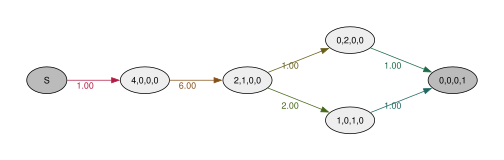

In [4]:
# Visualiser tilstandsrummet
graph.plot()

In [5]:
# Vis tilstandsrummet som tabel (mere læsevenligt end rå arrays)
labels = [f"{i+1}'ton" for i in range(nr_samples)]
df_states = pd.DataFrame(graph.states(), columns=labels)
df_states.index.name = 'Vertex'
print("Tilstandsrum (0 = start/absorb, øvrige = transiente tilstande):")
df_states

Tilstandsrum (0 = start/absorb, øvrige = transiente tilstande):


,1'ton,2'ton,3'ton,4'ton
Vertex,,,,
0,0,0,0,0
1,4,0,0,0
2,2,1,0,0
3,0,2,0,0
4,1,0,1,0
5,0,0,0,1


## TMRCA: momenter og fordeling

TMRCA er absorptionstiden $\tau \sim \text{PH}(\boldsymbol{\alpha}, \mathbf{S})$.

Jeg beregner først de eksakte momenter, derefter PDF og CDF, og til sidst verificerer jeg med Monte simuælering sampling.

In [6]:
# Eksakte momenter
E_tmrca = graph.expectation()
Var_tmrca = graph.variance()
moments_3 = graph.moments(3)

print(f"E[TMRCA]          = {E_tmrca:.6f}")
print(f"Var[TMRCA]        = {Var_tmrca:.6f}")
print(f"Std[TMRCA]        = {np.sqrt(Var_tmrca):.6f}")
print(f"Første 3 momenter = {[f'{m:.4f}' for m in moments_3]}")

# Analytisk forventningsværdi for sammenligning: E[TMRCA] = 2*(1 - 1/n)
E_analytisk = 2 * (1 - 1/nr_samples)
print(f"\nAnalytisk E[TMRCA] = 2(1-1/n) = {E_analytisk:.6f}")
print(f"Forskel            = {abs(E_tmrca - E_analytisk):.2e}")

E[TMRCA]          = 1.500000
Var[TMRCA]        = 1.138889
Std[TMRCA]        = 1.067187
Første 3 momenter = ['1.5000', '3.3889', '10.5833']

Analytisk E[TMRCA] = 2(1-1/n) = 1.500000
Forskel            = 4.44e-16


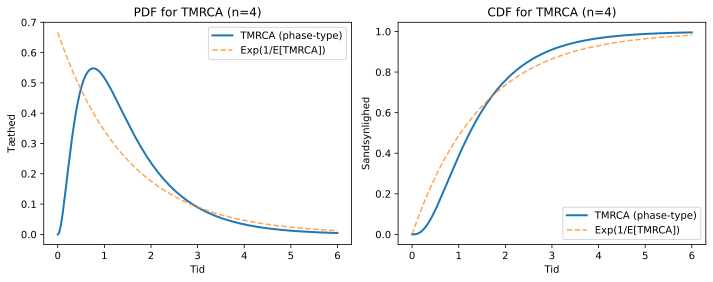

Observation: TMRCA er IKKE eksponentielt fordelt — formen er mere kompleks
fordi den er summen af afhængige eksponentielle ventetider.


In [7]:
# PDF og CDF — sammenlign med eksponentialfordeling
t = np.linspace(0, 6, 500)

pdf_tmrca = graph.pdf(t)
cdf_tmrca = graph.cdf(t)

# Eksponentialfordeling med samme mean (for sammenligning)
rate_exp = 1 / E_tmrca
pdf_exp = rate_exp * np.exp(-rate_exp * t)
cdf_exp = 1 - np.exp(-rate_exp * t)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(t, pdf_tmrca, label='TMRCA (phase-type)', lw=2)
axes[0].plot(t, pdf_exp, '--', label=f'Exp(1/E[TMRCA])', lw=1.5, alpha=0.7)
axes[0].set_xlabel('Tid')
axes[0].set_ylabel('Tæthed')
axes[0].set_title(f'PDF for TMRCA (n={nr_samples})')
axes[0].legend()

axes[1].plot(t, cdf_tmrca, label='TMRCA (phase-type)', lw=2)
axes[1].plot(t, cdf_exp, '--', label='Exp(1/E[TMRCA])', lw=1.5, alpha=0.7)
axes[1].set_xlabel('Tid')
axes[1].set_ylabel('Sandsynlighed')
axes[1].set_title(f'CDF for TMRCA (n={nr_samples})')
axes[1].legend()

plt.tight_layout()
plt.show()
print("Observation: TMRCA er IKKE eksponentielt fordelt — formen er mere kompleks")
print("fordi den er summen af afhængige eksponentielle ventetider.")

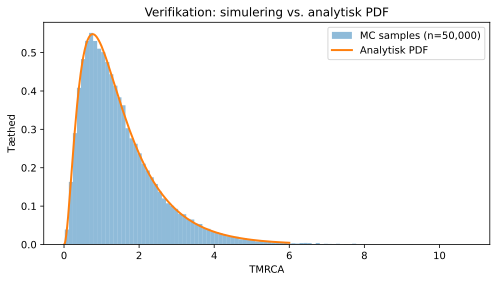

Simulering-gennemsnit: 1.5065
Analytisk E[TMRCA]: 1.5000
Simulering varians: 1.1328
Analytisk Var[TMRCA]:1.1389


In [12]:
# Verificer med simulering
n_samples = 50_000
samples = graph.sample(n_samples)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(samples, bins=100, density=True, alpha=0.5, label=f'MC samples (n={n_samples:,})')
ax.plot(t, pdf_tmrca, lw=2, label='Analytisk PDF')
ax.set_xlabel('TMRCA')
ax.set_ylabel('Tæthed')
ax.set_title('Verifikation: simulering vs. analytisk PDF')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Simulering-gennemsnit: {np.mean(samples):.4f}")
print(f"Analytisk E[TMRCA]: {E_tmrca:.4f}")
print(f"Simulering varians: {np.var(samples):.4f}")
print(f"Analytisk Var[TMRCA]:{Var_tmrca:.4f}")

## Sojourn-tider og tilstandssandsynligheder

Sojourn-tiden i tilstand $j$ er den forventede tid processen bruger i den tilstand inden absorption: $U_j = \boldsymbol{\alpha} (-\mathbf{S})^{-1} \mathbf{e}_j$.
Dette svarer til kolonnerne i Green-matricen.

In [13]:
# Forventet sojourn-tid i hver tilstand
sojourn = graph.expected_sojourn_time()

df_sojourn = pd.DataFrame({
    'Tilstand': range(len(sojourn)),
    'Tilstandsvektor': [str(list(s)) for s in graph.states()],
    'Sojourn-tid': sojourn
})
print("Forventet sojourn-tid i hver tilstand:")
print(df_sojourn.to_string(index=False))
print(f"\nSum (= E[TMRCA]): {sum(sojourn):.4f}")
print("\nObservation: De transiente tilstande med to linjer (tilstand 3 og 4)")
print("bruger dobbelt så lang tid som tilstand 2 fordi raten er halveret (1 vs 3).")

Forventet sojourn-tid i hver tilstand:
 Tilstand                                      Tilstandsvektor  Sojourn-tid
        0 [np.int32(0), np.int32(0), np.int32(0), np.int32(0)]     0.000000
        1 [np.int32(4), np.int32(0), np.int32(0), np.int32(0)]     0.166667
        2 [np.int32(2), np.int32(1), np.int32(0), np.int32(0)]     0.333333
        3 [np.int32(0), np.int32(2), np.int32(0), np.int32(0)]     0.333333
        4 [np.int32(1), np.int32(0), np.int32(1), np.int32(0)]     0.666667
        5 [np.int32(0), np.int32(0), np.int32(0), np.int32(1)]     0.000000

Sum (= E[TMRCA]): 1.5000

Observation: De transiente tilstande med to linjer (tilstand 3 og 4)
bruger dobbelt så lang tid som tilstand 2 fordi raten er halveret (1 vs 3).


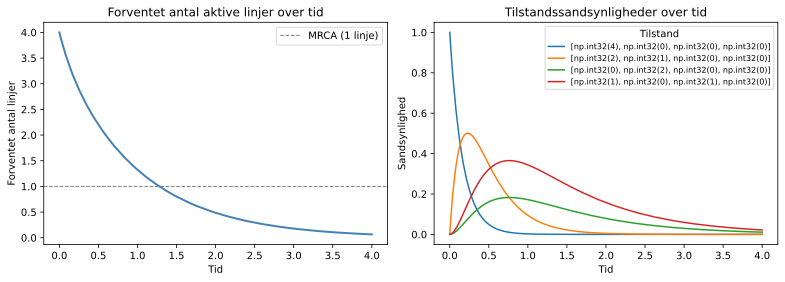

In [15]:
# Tilstandssandsynligheder over tid — hvad sker der?
times = np.linspace(0, 4, 300)
state_probs = np.array([graph.state_probability(t_i) for t_i in times])

# Forventet antal linjer over tid
total_lineages = np.sum(graph.states(), axis=1)  # antal linjer pr. tilstand
expected_lineages = state_probs @ total_lineages

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Plot 1: forventet antal linjer
axes[0].plot(times, expected_lineages, lw=2, color='steelblue')
axes[0].axhline(1, color='gray', linestyle='--', lw=1, label='MRCA (1 linje)')
axes[0].set_xlabel('Tid')
axes[0].set_ylabel('Forventet antal linjer')
axes[0].set_title('Forventet antal aktive linjer over tid')
axes[0].legend()

# Plot 2: sandsynlighed for at være i hver tilstand
state_labels = [str(list(s)) for s in graph.states()[1:-1]]  # skip start og absorb
for i, label in enumerate(state_labels):
    axes[1].plot(times, state_probs[:, i+1], label=label, lw=1.5)
axes[1].set_xlabel('Tid')
axes[1].set_ylabel('Sandsynlighed')
axes[1].set_title('Tilstandssandsynligheder over tid')
axes[1].legend(title='Tilstand', fontsize=8)

plt.tight_layout()
plt.show()

## Reward-transformationer og site frequency spectrum

Reward-vektoren $\mathbf{r}_i$ angiver antallet af $i$-ton linjer i hver tilstand.
Den akkumulerede reward $Y_i = \int_0^\tau r_i(X_t) \, dt$ er totallængden af grene med $i$ efterkommere. Det forventede SFS-entry er $\mathbb{E}[\xi_i] = (\theta/2) \mathbb{E}[Y_i]$.

In [16]:
# Reward-matrix: række i giver antal i-ton linjer i hver tilstand
reward_matrix = graph.states().T
print("Reward-matrix (rækker = linje-typer, kolonner = tilstande):")
df_rewards = pd.DataFrame(
    reward_matrix,
    index=[f'{i+1}-ton reward' for i in range(nr_samples)],
    columns=[f'T{i}' for i in range(graph.vertices_length())]
)
print(df_rewards)

Reward-matrix (rækker = linje-typer, kolonner = tilstande):
              T0  T1  T2  T3  T4  T5
1-ton reward   0   4   2   0   1   0
2-ton reward   0   0   1   2   0   0
3-ton reward   0   0   0   0   1   0
4-ton reward   0   0   0   0   0   1


In [17]:
# Forventet grenlængde for hver linje-type 
branch_expectations = [graph.expectation(r) for r in reward_matrix]
branch_variances = [graph.variance(r) for r in reward_matrix]

df_sfs = pd.DataFrame({
    'Linje-type': [f'{i+1}-ton' for i in range(nr_samples)],
    'E[grenlængde]': branch_expectations,
    'Var[grenlængde]': branch_variances
})
print("Forventede grenlængder:")
print(df_sfs.to_string(index=False))
print(f"\nSum E[grenlængder] = E[T_total] = {sum(branch_expectations):.4f}")

# Analytisk E[T_total] = 2 * sum(1/k for k=1..n-1)
E_total_analytisk = 2 * sum(1/k for k in range(1, nr_samples))
print(f"Analytisk E[T_total] = {E_total_analytisk:.4f}")

Forventede grenlængder:
Linje-type  E[grenlængde]  Var[grenlængde]
     1-ton       2.000000         1.777778
     2-ton       1.000000         2.333333
     3-ton       0.666667         0.888889
     4-ton       0.000000         0.000000

Sum E[grenlængder] = E[T_total] = 3.6667
Analytisk E[T_total] = 3.6667


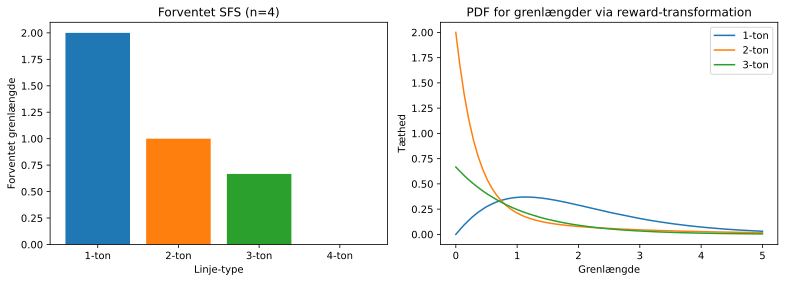

Observation: Singleton-grene er oftest korte; 'interne' grene har tungere haler.


In [18]:
# Plot SFS og PDF for hver grenlængde
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# SFS barplot
sfs_labels = [f'{i+1}-ton' for i in range(nr_samples)]
axes[0].bar(sfs_labels, branch_expectations, color=sns.color_palette('tab10', nr_samples))
axes[0].set_xlabel('Linje-type')
axes[0].set_ylabel('Forventet grenlængde')
axes[0].set_title(f'Forventet SFS (n={nr_samples})')

# PDF for hver grenlængde via reward-transformation
t_plot = np.linspace(0, 5, 400)
for i, r in enumerate(reward_matrix[:-1]):  # spring 4-ton over (altid 0)
    rt_graph = graph.reward_transform(r)
    axes[1].plot(t_plot, rt_graph.pdf(t_plot), label=f'{i+1}-ton', lw=1.5)

axes[1].set_xlabel('Grenlængde')
axes[1].set_ylabel('Tæthed')
axes[1].set_title('PDF for grenlængder via reward-transformation')
axes[1].legend()

plt.tight_layout()
plt.show()
print("Observation: Singleton-grene er oftest korte; 'interne' grene har tungere haler.")

## Hvad sker der, når vi varierer n?

Jeg bygger koalescenten for $n = 2, 3, \ldots, 15$ og undersøger, hvordan tilstandsrummets størrelse, TMRCA og variansen skalerer.

In [19]:
# Varier n og se hvordan E[TMRCA] og Var[TMRCA] ændrer sig
n_values = list(range(2, 16))
results = []

for n in n_values:
    @with_ipv([n] + [0] * (n - 1))
    def coal_n(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i + j + 1] += 1
                transitions.append((new, state[i] * (state[j] - same) / (1 + same)))
        return transitions

    g = Graph(coal_n)
    E_tmrca_n = g.expectation()
    Var_tmrca_n = g.variance()
    n_states = g.vertices_length() - 2  # minus start og absorb

    # Analytiske værdier
    E_ana = 2 * (1 - 1/n)
    Var_ana = sum(4 / (k**2 * (k-1)**2) for k in range(2, n+1))

    results.append({
        'n': n,
        'n_states': n_states,
        'E_phasic': E_tmrca_n,
        'E_analytisk': E_ana,
        'Var_phasic': Var_tmrca_n,
        'Var_analytisk': Var_ana
    })

df_n = pd.DataFrame(results)
print(df_n.to_string(index=False))

 n  n_states  E_phasic  E_analytisk  Var_phasic  Var_analytisk
 2         1  1.000000     1.000000    1.000000       1.000000
 3         2  1.333333     1.333333    1.111111       1.111111
 4         4  1.500000     1.500000    1.138889       1.138889
 5         6  1.600000     1.600000    1.148889       1.148889
 6        10  1.666667     1.666667    1.153333       1.153333
 7        14  1.714286     1.714286    1.155601       1.155601
 8        21  1.750000     1.750000    1.156876       1.156876
 9        29  1.777778     1.777778    1.157648       1.157648
10        41  1.800000     1.800000    1.158142       1.158142
11        55  1.818182     1.818182    1.158472       1.158472
12        76  1.833333     1.833333    1.158702       1.158702
13       100  1.846154     1.846154    1.158866       1.158866
14       134  1.857143     1.857143    1.158987       1.158987
15       175  1.866667     1.866667    1.159078       1.159078


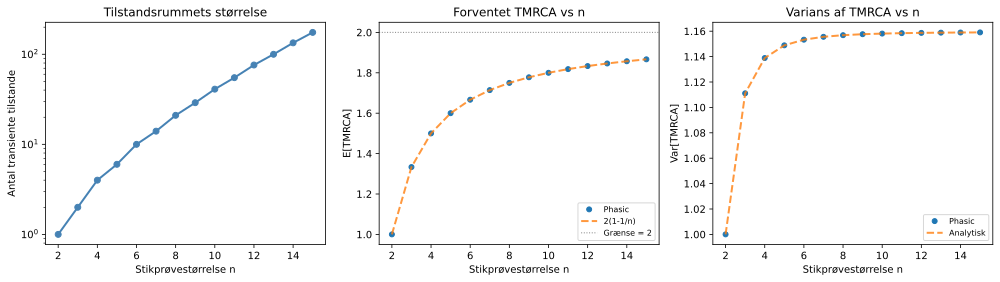

Observation: E[TMRCA] konvergerer hurtigt mod 2, men antallet af
tilstande vokser eksponentielt — computationel flaskehals for store n.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Antal tilstande vs n
axes[0].plot(df_n['n'], df_n['n_states'], 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('Stikprøvestørrelse n')
axes[0].set_ylabel('Antal transiente tilstande')
axes[0].set_title('Tilstandsrummets størrelse')
axes[0].set_yscale('log')

# E[TMRCA] vs n
axes[1].plot(df_n['n'], df_n['E_phasic'], 'o', label='Phasic', ms=5)
axes[1].plot(df_n['n'], df_n['E_analytisk'], '--', label='2(1-1/n)', lw=2, alpha=0.8)
axes[1].axhline(2, color='gray', linestyle=':', lw=1, label='Grænse = 2')
axes[1].set_xlabel('Stikprøvestørrelse n')
axes[1].set_ylabel('E[TMRCA]')
axes[1].set_title('Forventet TMRCA vs n')
axes[1].legend(fontsize=8)

# Var[TMRCA] vs n
axes[2].plot(df_n['n'], df_n['Var_phasic'], 'o', label='Phasic', ms=5)
axes[2].plot(df_n['n'], df_n['Var_analytisk'], '--', label='Analytisk', lw=2, alpha=0.8)
axes[2].set_xlabel('Stikprøvestørrelse n')
axes[2].set_ylabel('Var[TMRCA]')
axes[2].set_title('Varians af TMRCA vs n')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print("Observation: E[TMRCA] konvergerer hurtigt mod 2, men antallet af")
print("tilstande vokser eksponentielt — computationel flaskehals for store n.")

## Hvad sker der med PDF-formen for stigende n?

Plot PDF'en for TMRCA for $n = 2, 4, 8, 15$.

Hypotese: Fordelingen bliver mere koncentreret (relativt) tæt på $E[TMRCA] \approx 2$ for store $n$, fordi den første koalescenshændelse sker meget hurtigt.

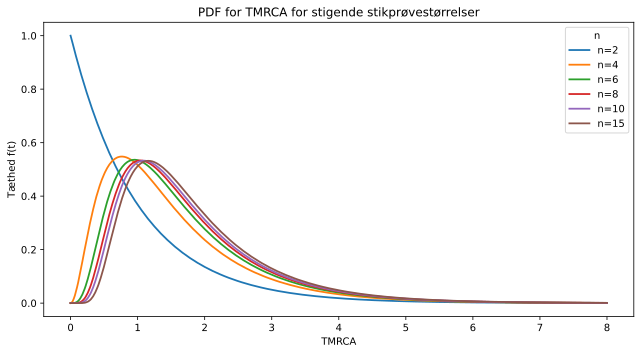

Observation:
- For n=2 er TMRCA ~ Exp(1), en simpel eksponentialfordeling.
- For større n opstår en tunge mod højre: den første koalescens sker
  hurtigt (høj rate), men de sidste linjer venter længe på hinanden.
- Tilsammen giver det en asymmetrisk, højreskæv fordeling.


In [21]:
n_plot = [2, 4, 6, 8, 10, 15]
t_plot = np.linspace(0, 8, 500)

fig, ax = plt.subplots(figsize=(9, 5))

for n in n_plot:
    @with_ipv([n] + [0] * (n - 1))
    def coal_pdf(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i + j + 1] += 1
                transitions.append((new, state[i] * (state[j] - same) / (1 + same)))
        return transitions

    g = Graph(coal_pdf)
    ax.plot(t_plot, g.pdf(t_plot), label=f'n={n}', lw=1.8)

ax.set_xlabel('TMRCA')
ax.set_ylabel('Tæthed f(t)')
ax.set_title('PDF for TMRCA for stigende stikprøvestørrelser')
ax.legend(title='n')
plt.tight_layout()
plt.show()

print("Observation:")
print("- For n=2 er TMRCA ~ Exp(1), en simpel eksponentialfordeling.")
print("- For større n opstår en tunge mod højre: den første koalescens sker")
print("  hurtigt (høj rate), men de sidste linjer venter længe på hinanden.")
print("- Tilsammen giver det en asymmetrisk, højreskæv fordeling.")

## Sub-intensitetsmatrixen og verifikation

Jeg kan trække matricerepræsentationen ud og verificere, at phasic's beregning er konsistent med den klassiske matrixformel $\mathbb{E}[\tau] = \boldsymbol{\alpha}(-\mathbf{S})^{-1}\mathbf{e}$.

In [22]:
# Udtræk matricer for n=4
graph = Graph(coalescent)  # genbyg n=4 grafen
mats = graph.as_matrices()

print("Initial sandsynlighedsvektor α:")
print(mats.ipv)
print("\nSub-intensitetsmatrix S:")
print(mats.sim)
print("\nTilstande (transiente):")
print(mats.states)

Initial sandsynlighedsvektor α:
[1. 0. 0. 0.]

Sub-intensitetsmatrix S:
[[-6.  6.  0.  0.]
 [ 0. -3.  1.  2.]
 [ 0.  0. -1.  0.]
 [ 0.  0.  0. -1.]]

Tilstande (transiente):
[[4 0 0 0]
 [2 1 0 0]
 [0 2 0 0]
 [1 0 1 0]]


In [23]:
# Verifikation: E[TMRCA] = α (-S)^{-1} e
S = mats.sim
alpha = mats.ipv
e = np.ones(S.shape[0])

neg_S_inv = np.linalg.inv(-S)  # = Green-matricen U
E_matrix = alpha @ neg_S_inv @ e

print(f"E[TMRCA] via matricer: {E_matrix:.8f}")
print(f"E[TMRCA] via phasic: {graph.expectation():.8f}")
print(f"Forskel: {abs(E_matrix - graph.expectation()):.2e}")

print("\nGreen-matricen U = (-S)^{-1} (forventet tid i tilstand j givet start i tilstand i):")
print(np.round(neg_S_inv, 4))

print("\nForventet sojourn-tid i hver tilstand (= diagonalen i α·U):")
sojourn_matrix = alpha @ neg_S_inv
print(np.round(sojourn_matrix, 4))
print("\nSammen stemmer dette med graph.expected_sojourn_time() fra phasic.")

E[TMRCA] via matricer: 1.50000000
E[TMRCA] via phasic: 1.50000000
Forskel: 0.00e+00

Green-matricen U = (-S)^{-1} (forventet tid i tilstand j givet start i tilstand i):
[[0.1667 0.3333 0.3333 0.6667]
 [0.     0.3333 0.3333 0.6667]
 [0.     0.     1.     0.    ]
 [0.     0.     0.     1.    ]]

Forventet sojourn-tid i hver tilstand (= diagonalen i α·U):
[0.1667 0.3333 0.3333 0.6667]

Sammen stemmer dette med graph.expected_sojourn_time() fra phasic.


## SFS som funktion af n hvad sker der?

Beregner det forventede SFS for $n = 4, 8, 12$ og sammenlign formerne. Teorien forudsiger $\mathbb{E}[\xi_i] \propto \theta / i$ for Kingman's koalescent (det harmoniske mønster).

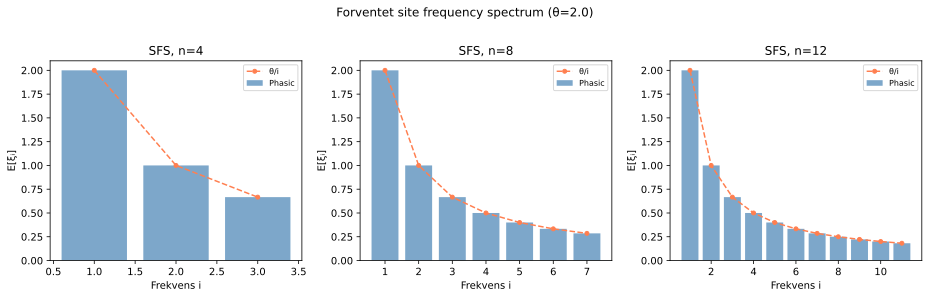

Observation: SFS følger det harmoniske mønster θ/i for Kingman's koalescent.
Singletons dominerer — mutations der kun ses i ét individ er de hyppigste.


In [24]:
theta = 2.0  # skaleret mutationsrate
sfs_n_values = [4, 8, 12]

fig, axes = plt.subplots(1, len(sfs_n_values), figsize=(13, 4), sharey=False)

for ax, n in zip(axes, sfs_n_values):
    @with_ipv([n] + [0] * (n - 1))
    def coal_sfs(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i + j + 1] += 1
                transitions.append((new, state[i] * (state[j] - same) / (1 + same)))
        return transitions

    g = Graph(coal_sfs)
    rmat = g.states().T

    # Forventet SFS: E[xi_i] = (theta/2) * E[Y_i]
    sfs_vals = [(theta / 2) * g.expectation(r) for r in rmat[:-1]]
    # Harmonisk forventning: theta/i
    sfs_harmonisk = [theta / i for i in range(1, n)]

    x = range(1, n)
    ax.bar(x, sfs_vals, alpha=0.7, label='Phasic', color='steelblue')
    ax.plot(x, sfs_harmonisk, 'o--', color='coral', lw=1.5, ms=4, label='θ/i')
    ax.set_xlabel('Frekvens i')
    ax.set_ylabel('E[ξᵢ]')
    ax.set_title(f'SFS, n={n}')
    ax.legend(fontsize=8)

plt.suptitle(f'Forventet site frequency spectrum (θ={theta})', y=1.02)
plt.tight_layout()
plt.show()
print("Observation: SFS følger det harmoniske mønster θ/i for Kingman's koalescent.")
print("Singletons dominerer — mutations der kun ses i ét individ er de hyppigste.")

## Opsummering

| Observation | Konklusion |
|---|---|
| E[TMRCA] → 2 for store n | TMRCA er domineret af de første koalescenshændelser |
| Tilstandsrum vokser hurtigt | Beregningsmæssig flaskehals for n > 20 |
| PDF er højreskæv | Summen af afhængige exp-variable, ikke selv exp-fordelt |
| SFS ~ θ/i | Kingman's koalescent giver harmonisk mønster |
| Phasic og matrix-formlerne er numerisk identiske | Korrekt implementering |

**Næste notebook:** 02_phase_type_basics.ipynb — sojourn-tider i dybden og hvad der sker, hvis vi tilføjer populationsstørrelse N som parameter.